Latest observation: 2026-08-26
2Y:  4.62%
3Y:  4.60%
5Y:  4.66%
10Y: 5.02%


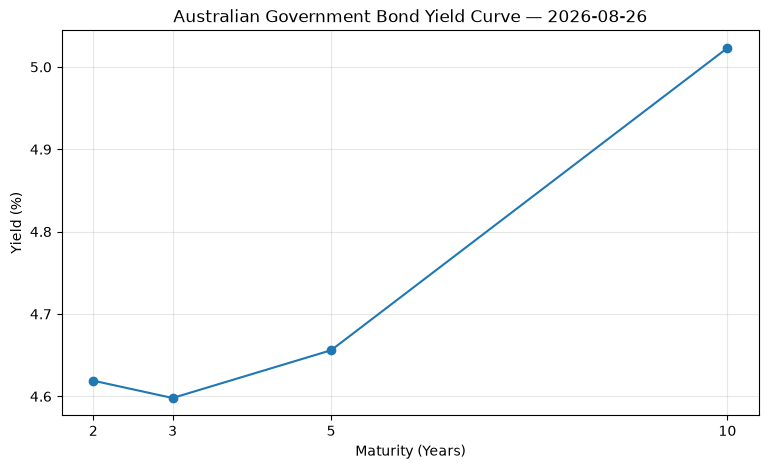

2s10s: 40.4 bp
3s10s: 42.5 bp
2s5s:  3.7 bp
Latest: 2026-08-26 00:00:00
1 month ago: 2026-07-24 00:00:00
6 months ago: 2026-02-26 00:00:00
1 year ago: 2025-08-26 00:00:00


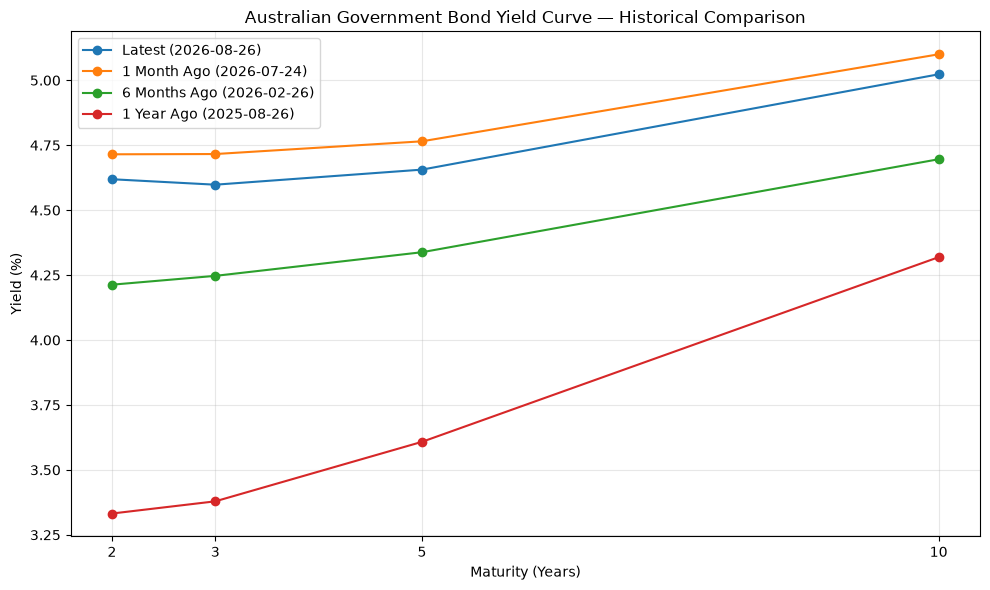

,Period,Date,2Y,3Y,5Y,10Y,2s10s_bp
0,Latest,2026-08-26,4.619,4.598,4.656,5.023,40.4
1,1 Month Ago,2026-07-24,4.715,4.716,4.765,5.100,38.5
2,6 Months Ago,2026-02-26,4.213,4.247,4.338,4.696,48.3
3,1 Year Ago,2025-08-26,3.332,3.379,3.608,4.319,98.7


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RBA_F2_URL = "https://www.rba.gov.au/statistics/tables/xls/f02d.xlsx"

raw = pd.read_excel(
    RBA_F2_URL,
    sheet_name="Data",
    header=None
)

raw.head(15)
raw.iloc[10:20, :5]
# Keep only Date, 2Y, 3Y, 5Y and 10Y columns
yields = raw.iloc[11:, :5].copy()

# Give them clean names
yields.columns = ["Date", "2Y", "3Y", "5Y", "10Y"]

# Convert dates
yields["Date"] = pd.to_datetime(yields["Date"], errors="coerce")

# Convert yield columns to numbers
for col in ["2Y", "3Y", "5Y", "10Y"]:
    yields[col] = pd.to_numeric(yields[col], errors="coerce")

# Remove rows without a valid date
yields = yields.dropna(subset=["Date"])

# Sort chronologically
yields = yields.sort_values("Date").reset_index(drop=True)

yields.tail(10)

latest = yields.iloc[-1]

latest

print("Latest observation:", latest["Date"].date())
print(f"2Y:  {latest['2Y']:.2f}%")
print(f"3Y:  {latest['3Y']:.2f}%")
print(f"5Y:  {latest['5Y']:.2f}%")
print(f"10Y: {latest['10Y']:.2f}%")

yields["2s10s_bp"] = (yields["10Y"] - yields["2Y"]) * 100
yields["3s10s_bp"] = (yields["10Y"] - yields["3Y"]) * 100
yields["2s5s_bp"] = (yields["5Y"] - yields["2Y"]) * 100

yields.tail()

maturities = [2, 3, 5, 10]
latest_yields = [
    latest["2Y"],
    latest["3Y"],
    latest["5Y"],
    latest["10Y"]
]

plt.figure(figsize=(9, 5))
plt.plot(maturities, latest_yields, marker="o")

plt.title(
    f"Australian Government Bond Yield Curve — {latest['Date'].date()}"
)
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.xticks(maturities)
plt.grid(alpha=0.3)

plt.show()

yields.to_csv(
    "../data/processed/au_government_yields.csv",
    index=False
)

check = pd.read_csv(
    "../data/processed/au_government_yields.csv",
    parse_dates=["Date"]
)

check.tail()

latest = yields.iloc[-1]

current_2s10s = (latest["10Y"] - latest["2Y"]) * 100
current_3s10s = (latest["10Y"] - latest["3Y"]) * 100
current_2s5s = (latest["5Y"] - latest["2Y"]) * 100

print(f"2s10s: {current_2s10s:.1f} bp")
print(f"3s10s: {current_3s10s:.1f} bp")
print(f"2s5s:  {current_2s5s:.1f} bp")

latest_date = yields["Date"].max()

def get_observation_on_or_before(target_date):
    available = yields[yields["Date"] <= target_date]

    if available.empty:
        return None

    return available.iloc[-1]

latest_obs = get_observation_on_or_before(latest_date)

one_month_obs = get_observation_on_or_before(
    latest_date - pd.DateOffset(months=1)
)

six_month_obs = get_observation_on_or_before(
    latest_date - pd.DateOffset(months=6)
)

one_year_obs = get_observation_on_or_before(
    latest_date - pd.DateOffset(years=1)
)

print("Latest:", latest_obs["Date"])
print("1 month ago:", one_month_obs["Date"])
print("6 months ago:", six_month_obs["Date"])
print("1 year ago:", one_year_obs["Date"])

maturities = [2, 3, 5, 10]
tenors = ["2Y", "3Y", "5Y", "10Y"]

plt.figure(figsize=(10, 6))

plt.plot(
    maturities,
    [latest_obs[x] for x in tenors],
    marker="o",
    label=f"Latest ({latest_obs['Date'].date()})"
)

plt.plot(
    maturities,
    [one_month_obs[x] for x in tenors],
    marker="o",
    label=f"1 Month Ago ({one_month_obs['Date'].date()})"
)

plt.plot(
    maturities,
    [six_month_obs[x] for x in tenors],
    marker="o",
    label=f"6 Months Ago ({six_month_obs['Date'].date()})"
)

plt.plot(
    maturities,
    [one_year_obs[x] for x in tenors],
    marker="o",
    label=f"1 Year Ago ({one_year_obs['Date'].date()})"
)

plt.title("Australian Government Bond Yield Curve — Historical Comparison")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.xticks(maturities)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/australian_yield_curve_historical_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

comparison = pd.DataFrame({
    "Period": [
        "Latest",
        "1 Month Ago",
        "6 Months Ago",
        "1 Year Ago"
    ],
    "Date": [
        latest_obs["Date"],
        one_month_obs["Date"],
        six_month_obs["Date"],
        one_year_obs["Date"]
    ],
    "2Y": [
        latest_obs["2Y"],
        one_month_obs["2Y"],
        six_month_obs["2Y"],
        one_year_obs["2Y"]
    ],
    "3Y": [
        latest_obs["3Y"],
        one_month_obs["3Y"],
        six_month_obs["3Y"],
        one_year_obs["3Y"]
    ],
    "5Y": [
        latest_obs["5Y"],
        one_month_obs["5Y"],
        six_month_obs["5Y"],
        one_year_obs["5Y"]
    ],
    "10Y": [
        latest_obs["10Y"],
        one_month_obs["10Y"],
        six_month_obs["10Y"],
        one_year_obs["10Y"]
    ]
})

comparison["2s10s_bp"] = (
    comparison["10Y"] - comparison["2Y"]
) * 100

comparison

## Market Interpretation

As of 26 August 2026, the Australian Government bond curve is upward
sloping overall, with the 2-year yield at 4.619% and the 10-year yield
at 5.023%, producing a positive 2s10s spread of approximately 40 bp.

The front and middle of the curve are relatively flat, with the 2-year,
3-year and 5-year yields clustered around 4.60–4.66%, before the curve
steepens more noticeably toward the 10-year maturity.

Over the past month, yields declined across all four maturities, with
front-end yields falling slightly more than the 10-year yield. This
resulted in a modest bull steepening of the 2s10s curve.

The longer-term change is more significant. Relative to one year ago,
the 2-year yield has increased by approximately 129 bp compared with
around 70 bp for the 10-year yield. The 2s10s spread has consequently
compressed from approximately 99 bp to 40 bp, representing a pronounced
bear flattening.

This indicates that repricing has been considerably stronger at the
front end of the Australian curve. This is consistent with a material
reassessment of near-term monetary-policy expectations relative to
longer-term rates. However, the yield data alone cannot establish the
cause of these movements. The next stage of the project therefore
examines yield changes around RBA monetary-policy decisions.

In [14]:
def yield_change_bp(current, previous, tenor):
    return (current[tenor] - previous[tenor]) * 100

change_summary = pd.DataFrame({
    "Period": [
        "1 Month",
        "6 Months",
        "1 Year"
    ],
    "2Y Change (bp)": [
        yield_change_bp(latest_obs, one_month_obs, "2Y"),
        yield_change_bp(latest_obs, six_month_obs, "2Y"),
        yield_change_bp(latest_obs, one_year_obs, "2Y")
    ],
    "3Y Change (bp)": [
        yield_change_bp(latest_obs, one_month_obs, "3Y"),
        yield_change_bp(latest_obs, six_month_obs, "3Y"),
        yield_change_bp(latest_obs, one_year_obs, "3Y")
    ],
    "5Y Change (bp)": [
        yield_change_bp(latest_obs, one_month_obs, "5Y"),
        yield_change_bp(latest_obs, six_month_obs, "5Y"),
        yield_change_bp(latest_obs, one_year_obs, "5Y")
    ],
    "10Y Change (bp)": [
        yield_change_bp(latest_obs, one_month_obs, "10Y"),
        yield_change_bp(latest_obs, six_month_obs, "10Y"),
        yield_change_bp(latest_obs, one_year_obs, "10Y")
    ]
})

change_summary = change_summary.round(1)

change_summary

,Period,2Y Change (bp),3Y Change (bp),5Y Change (bp),10Y Change (bp)
0,1 Month,-9.6,-11.8,-10.9,-7.7
1,6 Months,40.6,35.1,31.8,32.7
2,1 Year,128.7,121.9,104.8,70.4


In [ ]:
change_summary.to_csv(
    "../outputs/tables/yield_changes_summary.csv",
    index=False
)

comparison.to_csv(
    "../outputs/tables/yield_curve_comparison.csv",
    index=False
)

print("Tables saved successfully.")

Tables saved successfully.


<Figure size 640x480 with 0 Axes>